# Wind Event in Jun 2026 and Jul 2026 at Juan de Fuca Strait

SalishSeaCast results show an oxygen-depletion around Juan de Fuca in July 2026, possibly caused by coastal upwelling.

In [ ]:
# Path and location

# location: 48.5, 125.00

# HRDPS path: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_yYYYYmMMdDD.nc'
# Example: '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2026m07d20.nc'
# Variables: 'u_wind', 'u_wind'
# Dimension: 'time_counter', 'nav_lat', 'nav_lon'

In [ ]:
#!/usr/bin/env python3
"""


wind_NW45 > 0 : wind vector points toward NW
wind_NW45 < 0 : wind vector points toward SE
"""

from pathlib import Path
from datetime import datetime
import re

import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# User settings
# ============================================================

TARGET_LAT = 48.5
TARGET_LON = -125.0

START_DATE = pd.Timestamp("2026-06-01")
END_DATE = pd.Timestamp.today().normalize()

HRDPS_DIR = Path(
    "/results/forcing/atmospheric/continental2.5/nemo_forcing"
)

OUTPUT_CSV = Path(
    f"hrdps_wind_{TARGET_LAT:.2f}N_{abs(TARGET_LON):.2f}W_"
    f"{START_DATE:%Y%m%d}_to_{END_DATE:%Y%m%d}.csv"
)

U_NAME = "u_wind"
V_NAME = "v_wind"


# ============================================================
# Helper functions
# ============================================================

def longitude_difference(lon: np.ndarray, target_lon: float) -> np.ndarray:
    """
    Return the shortest signed longitude difference in degrees.

    This works whether longitude is represented as:
        -180 to 180
    or:
        0 to 360
    """
    return (lon - target_lon + 180.0) % 360.0 - 180.0


def find_nearest_grid_point(
    nav_lat: np.ndarray,
    nav_lon: np.ndarray,
    target_lat: float,
    target_lon: float,
) -> tuple[int, int]:
    """
    Find the nearest grid point using an approximate spherical distance.

    Returns
    -------
    j, i
        Indices of the nearest point in the two-dimensional spatial grid.
    """
    dlat = nav_lat - target_lat
    dlon = longitude_difference(nav_lon, target_lon)

    # Account approximately for longitude convergence with latitude.
    distance_squared = (
        dlat**2
        + (dlon * np.cos(np.deg2rad(target_lat)))**2
    )

    if np.all(np.isnan(distance_squared)):
        raise ValueError("All navigation-coordinate distances are NaN.")

    return np.unravel_index(
        np.nanargmin(distance_squared),
        distance_squared.shape,
    )


def date_from_filename(path: Path) -> pd.Timestamp | None:
    """
    Extract YYYY, MM and DD from a filename such as:
    hrdps_y2026m07d20.nc
    """
    match = re.search(
        r"hrdps_y(\d{4})m(\d{2})d(\d{2})\.nc$",
        path.name,
    )

    if match is None:
        return None

    year, month, day = map(int, match.groups())
    return pd.Timestamp(year=year, month=month, day=day)


def get_input_files(
    directory: Path,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> list[Path]:
    """Return existing HRDPS files within the requested date range."""
    selected_files = []

    for path in sorted(directory.glob("hrdps_y????m??d??.nc")):
        file_date = date_from_filename(path)

        if file_date is None:
            continue

        if start_date <= file_date <= end_date:
            selected_files.append(path)

    return selected_files


def identify_spatial_dimensions(
    data_array: xr.DataArray,
    nav_lat: xr.DataArray,
) -> tuple[str, str]:
    """
    Determine the two spatial dimension names.

    Usually nav_lat/nav_lon have dimensions such as:
        ('y', 'x')
    even though their variable names are nav_lat and nav_lon.
    """
    if nav_lat.ndim != 2:
        raise ValueError(
            f"Expected nav_lat to be two-dimensional, got {nav_lat.dims}."
        )

    y_dim, x_dim = nav_lat.dims

    if y_dim not in data_array.dims or x_dim not in data_array.dims:
        raise ValueError(
            f"Wind variable dimensions {data_array.dims} do not contain "
            f"navigation dimensions {(y_dim, x_dim)}."
        )

    return y_dim, x_dim


def extract_one_file(
    path: Path,
    j: int,
    i: int,
    y_dim: str,
    x_dim: str,
) -> pd.DataFrame:
    """Extract the wind time series from one daily HRDPS file."""
    with xr.open_dataset(path) as ds:
        missing = [
            name for name in (U_NAME, V_NAME, "time_counter")
            if name not in ds.variables and name not in ds.coords
        ]

        if missing:
            raise KeyError(
                f"{path.name} is missing variables/coordinates: {missing}. "
                f"Available data variables: {list(ds.data_vars)}"
            )

        indexer = {y_dim: j, x_dim: i}

        u = ds[U_NAME].isel(indexer).squeeze(drop=True)
        v = ds[V_NAME].isel(indexer).squeeze(drop=True)

        # Load before closing the NetCDF file.
        u_values = np.asarray(u.load().values).reshape(-1)
        v_values = np.asarray(v.load().values).reshape(-1)

        times = pd.to_datetime(
            np.asarray(ds["time_counter"].values).reshape(-1)
        )

    if not (len(times) == len(u_values) == len(v_values)):
        raise ValueError(
            f"Time and wind-array lengths differ in {path.name}: "
            f"time={len(times)}, u={len(u_values)}, v={len(v_values)}"
        )

    frame = pd.DataFrame(
        {
            "time": times,
            "u_wind": u_values,
            "v_wind": v_values,
        }
    )

    frame["source_file"] = path.name
    return frame


# ============================================================
# Main calculation
# ============================================================

def main() -> None:
    files = get_input_files(
        directory=HRDPS_DIR,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    if not files:
        raise FileNotFoundError(
            f"No HRDPS files were found in {HRDPS_DIR} between "
            f"{START_DATE:%Y-%m-%d} and {END_DATE:%Y-%m-%d}."
        )

    print(f"Found {len(files)} files.")
    print(f"First file: {files[0]}")
    print(f"Last file:  {files[-1]}")

    # Read the grid from the first available file.
    with xr.open_dataset(files[0]) as grid_ds:
        if "nav_lat" not in grid_ds or "nav_lon" not in grid_ds:
            raise KeyError(
                f"{files[0].name} does not contain nav_lat and nav_lon."
            )

        nav_lat_da = grid_ds["nav_lat"].squeeze()
        nav_lon_da = grid_ds["nav_lon"].squeeze()

        nav_lat = np.asarray(nav_lat_da.values)
        nav_lon = np.asarray(nav_lon_da.values)

        if nav_lat.shape != nav_lon.shape:
            raise ValueError(
                f"nav_lat shape {nav_lat.shape} differs from "
                f"nav_lon shape {nav_lon.shape}."
            )

        j, i = find_nearest_grid_point(
            nav_lat=nav_lat,
            nav_lon=nav_lon,
            target_lat=TARGET_LAT,
            target_lon=TARGET_LON,
        )

        actual_lat = float(nav_lat[j, i])
        actual_lon = float(nav_lon[j, i])

        y_dim, x_dim = identify_spatial_dimensions(
            grid_ds[U_NAME],
            nav_lat_da,
        )

    print(f"Target location:  {TARGET_LAT:.5f}, {TARGET_LON:.5f}")
    print(f"Nearest grid:    {actual_lat:.5f}, {actual_lon:.5f}")
    print(f"Grid indices:    {y_dim}={j}, {x_dim}={i}")

    daily_frames = []

    for number, path in enumerate(files, start=1):
        print(f"[{number:03d}/{len(files):03d}] Reading {path.name}")

        frame = extract_one_file(
            path=path,
            j=j,
            i=i,
            y_dim=y_dim,
            x_dim=x_dim,
        )

        daily_frames.append(frame)

    wind = pd.concat(daily_frames, ignore_index=True)

    # Restrict using actual timestamps, rather than filenames alone.
    end_exclusive = END_DATE + pd.Timedelta(days=1)

    wind = wind.loc[
        (wind["time"] >= START_DATE)
        & (wind["time"] < end_exclusive)
    ].copy()

    # Remove duplicate timestamps in case adjacent files overlap.
    wind = (
        wind.sort_values("time")
        .drop_duplicates(subset="time", keep="last")
        .reset_index(drop=True)
    )

    # Unit vector pointing toward northwest:
    #
    # eastward component = -1/sqrt(2)
    # northward component = +1/sqrt(2)
    #
    # Projection = u * e_NW + v * n_NW
    wind["wind_NW45"] = (
        -wind["u_wind"] + wind["v_wind"]
    ) / np.sqrt(2.0)

    # Opposite sign, included for convenience:
    # positive means the wind vector points toward southeast.
    wind["wind_SE45"] = -wind["wind_NW45"]

    wind["wind_speed"] = np.hypot(
        wind["u_wind"],
        wind["v_wind"],
    )

    wind["target_lat"] = TARGET_LAT
    wind["target_lon"] = TARGET_LON
    wind["grid_lat"] = actual_lat
    wind["grid_lon"] = actual_lon
    wind["grid_j"] = j
    wind["grid_i"] = i

    output_columns = [
        "time",
        "u_wind",
        "v_wind",
        "wind_speed",
        "wind_NW45",
        "wind_SE45",
        "target_lat",
        "target_lon",
        "grid_lat",
        "grid_lon",
        "grid_j",
        "grid_i",
        "source_file",
    ]

    wind.to_csv(
        OUTPUT_CSV,
        columns=output_columns,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
        float_format="%.6f",
    )

    print()
    print(f"Saved {len(wind)} records to:")
    print(OUTPUT_CSV.resolve())


if __name__ == "__main__":
    main()

读取记录数：1200
起始时间：2026-06-01 00:00:00
结束时间：2026-07-20 23:00:00
NW45 平均风速：-1.684 m/s


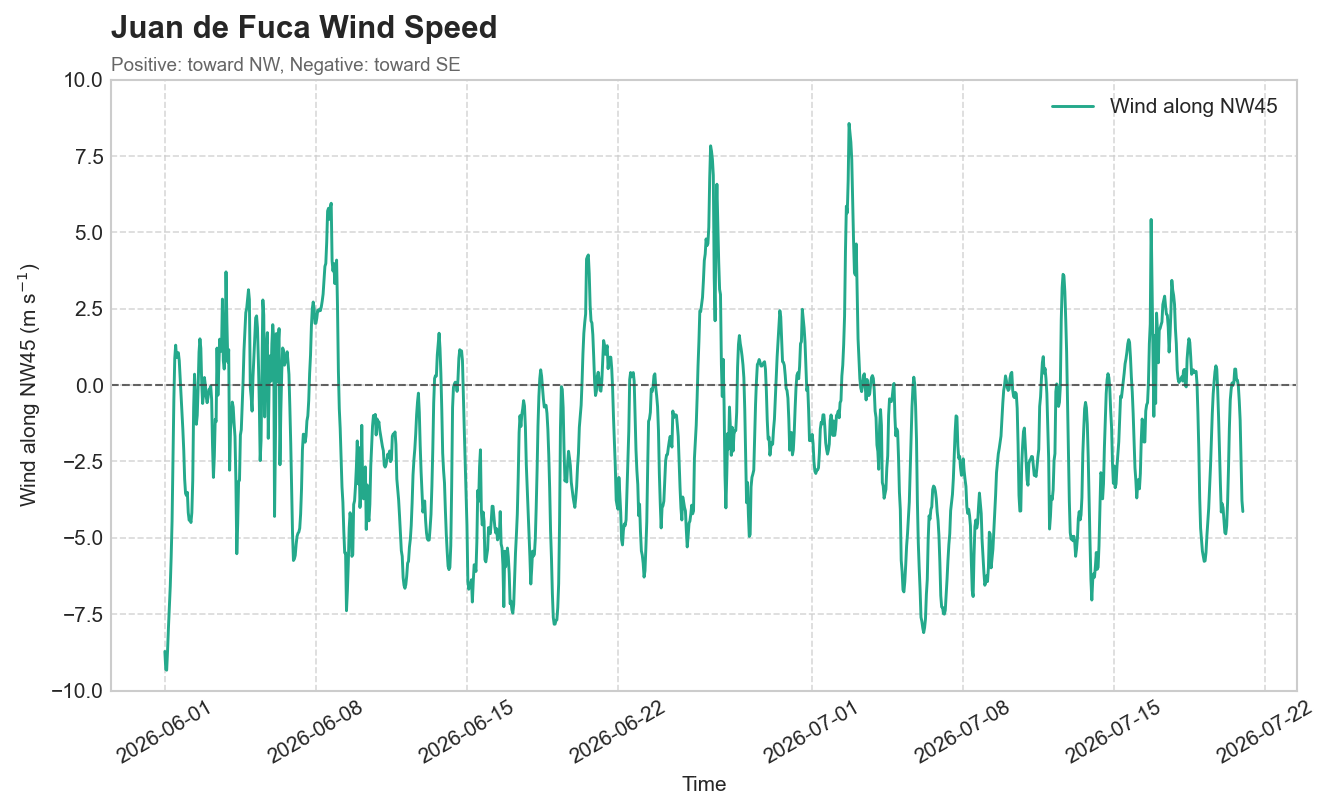

In [9]:
# Visualization

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cmocean

plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 数据读取
# -----------------------------------------------------------------------------

CSV_PATH = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/hrdps_wind_202606.csv"
)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"找不到 CSV 文件：{CSV_PATH.resolve()}")

wind = pd.read_csv(
    CSV_PATH,
    parse_dates=["time"],
)

required_columns = {
    "time",
    "u_wind",
    "v_wind",
    "wind_speed",
    "wind_NW45",
}

missing_columns = required_columns.difference(wind.columns)

if missing_columns:
    raise KeyError(
        f"CSV 缺少以下列：{sorted(missing_columns)}\n"
        f"现有列：{list(wind.columns)}"
    )

# 清理无效值并按时间排序
wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)

date = wind["time"]
wind_nw45 = wind["wind_NW45"]

print(f"读取记录数：{len(wind)}")
print(f"起始时间：{date.min()}")
print(f"结束时间：{date.max()}")
print(f"NW45 平均风速：{wind_nw45.mean():.3f} m/s")


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.plot(
    date,
    wind_nw45,
    color="#24a98b",
    lw=1.4,
    label="Wind along NW45",
)

# 零线：区分指向 NW 和指向 SE 的风
ax.axhline(
    0,
    color="0.25",
    lw=1,
    linestyle="--",
    alpha=0.8,
)

ax.tick_params(axis="x", rotation=30)

ax.set_title(
    "Juan de Fuca Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Wind along NW45 (m s$^{-1}$)")

ax.grid(
    True,
    alpha=0.75,
    linestyle="--",
)

ax.legend(
    loc="best",
    frameon=False,
)

ax.set_ylim(-10,10)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()
plt.show()

Mean NW45 Windspeed：-1.684 m/s


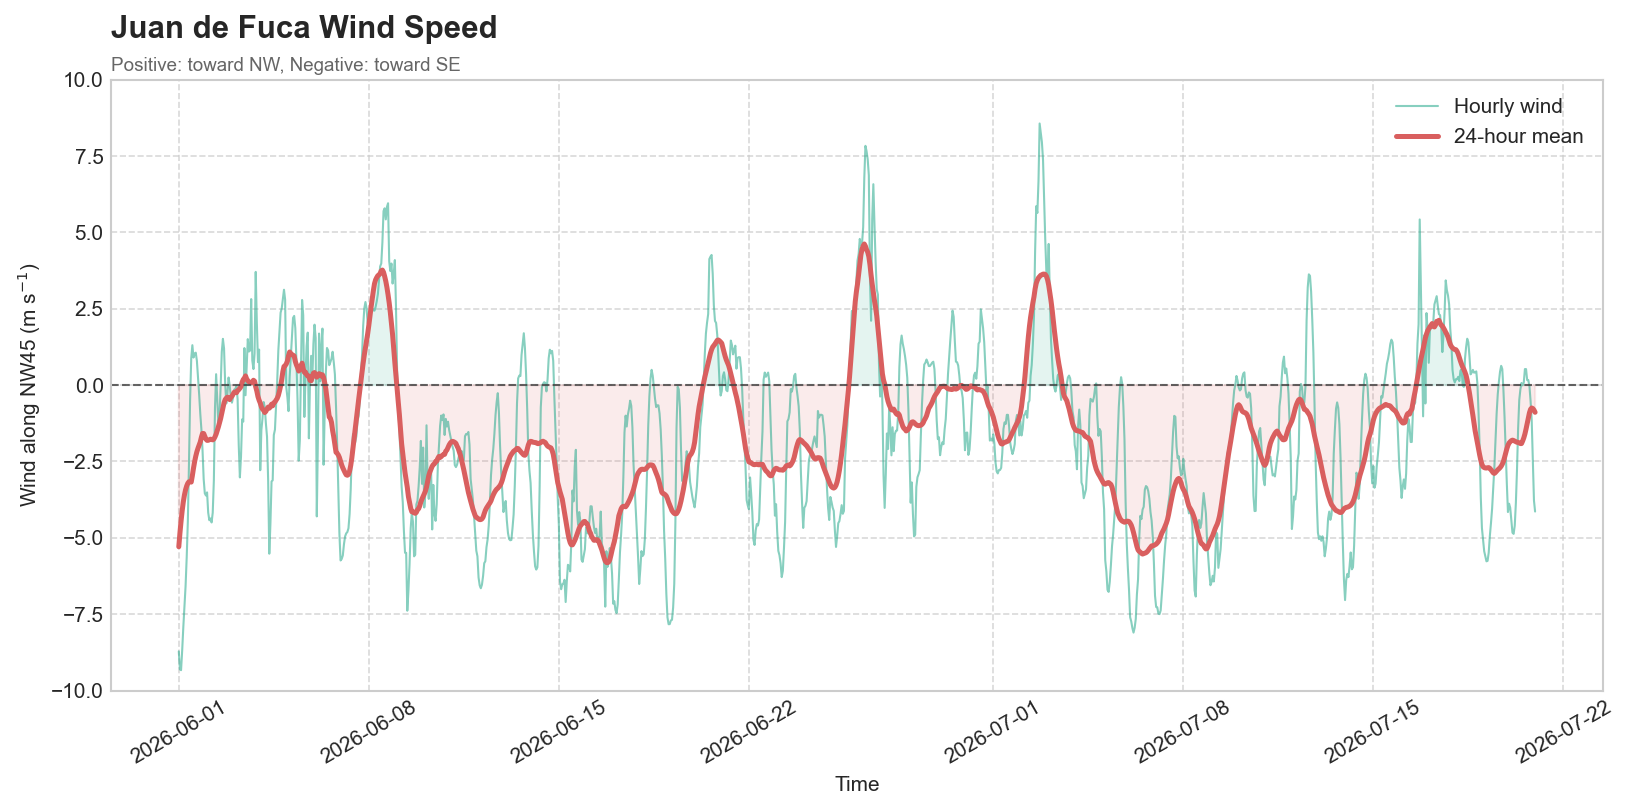

In [8]:
# 24h Smooth

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")


# -----------------------------------------------------------------------------
# 设置
# -----------------------------------------------------------------------------

CSV_PATH = Path(
    "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_atmo_events/hrdps_wind_202606.csv"
)

ROLLING_WINDOW = "24h"


# -----------------------------------------------------------------------------
# 数据读取与处理
# -----------------------------------------------------------------------------

if not CSV_PATH.exists():
    raise FileNotFoundError(f"找不到 CSV 文件：{CSV_PATH.resolve()}")

wind = pd.read_csv(
    CSV_PATH,
    parse_dates=["time"],
)

required_columns = ["time", "wind_NW45"]
missing_columns = [
    column for column in required_columns
    if column not in wind.columns
]

if missing_columns:
    raise KeyError(
        f"CSV 缺少列：{missing_columns}；"
        f"现有列为：{list(wind.columns)}"
    )

wind = (
    wind.dropna(subset=["time", "wind_NW45"])
    .sort_values("time")
    .drop_duplicates(subset="time", keep="last")
    .reset_index(drop=True)
)

if wind.empty:
    raise ValueError("清理后没有可用于绘图的数据。")

# 使用时间索引，使 rolling('24h') 按真实时间窗口计算
wind = wind.set_index("time")

wind["wind_NW45_24h"] = (
    wind["wind_NW45"]
    .rolling(
        ROLLING_WINDOW,
        center=True,
        min_periods=6,
    )
    .mean()
)


print(f"Mean NW45 Windspeed：{wind['wind_NW45'].mean():.3f} m/s")


# -----------------------------------------------------------------------------
# 绘图
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 5.5),
    dpi=150,
)

# 原始风速
ax.plot(
    wind.index,
    wind["wind_NW45"],
    color="#24a98b",
    lw=1.0,
    alpha=0.55,
    label="Hourly wind",
)

# 24 小时滑动平均
ax.plot(
    wind.index,
    wind["wind_NW45_24h"],
    color="#d95f5f",
    lw=2.4,
    label="24-hour mean",
)

# 零风速参考线
ax.axhline(
    y=0,
    color="0.25",
    lw=1.0,
    linestyle="--",
    alpha=0.8,
)

# 可选：对正负方向增加淡色背景
ax.fill_between(
    wind.index,
    0,
    wind["wind_NW45_24h"],
    where=wind["wind_NW45_24h"] >= 0,
    interpolate=True,
    color="#24a98b",
    alpha=0.12,
)

ax.fill_between(
    wind.index,
    0,
    wind["wind_NW45_24h"],
    where=wind["wind_NW45_24h"] < 0,
    interpolate=True,
    color="#d95f5f",
    alpha=0.12,
)

ax.set_title(
    "Juan de Fuca Wind Speed",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

ax.text(
    0,
    1.015,
    "Positive: toward NW, Negative: toward SE",
    transform=ax.transAxes,
    color="0.4",
    fontsize=9,
)

ax.set_xlabel("Time")
ax.set_ylabel("Wind along NW45 (m s$^{-1}$)")

ax.set_ylim(-10,10)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.grid(
    True,
    alpha=0.75,
    linestyle="--",
)

ax.legend(
    loc="best",
    frameon=False,
)

fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

fig.tight_layout()
plt.show()